# Baseline Multilayer Perceptron (MLP)

In [37]:
import os
import sys

# Check if running in Google Colab
if 'google.colab' in sys.modules:
    # Clone your repository if it hasn't been cloned yet
    if not os.path.exists('/content/svi-fema-spatial-graph-modeling'):
        !git clone https://github.com/AnhJoe/svi-fema-spatial-graph-modeling.git
    
    # Change working directory to the project root
    os.chdir('/content/svi-fema-spatial-graph-modeling')

In [38]:
#| output: false

import sys
from pathlib import Path

# Set to root for src load
root = Path.cwd()
while root != root.parent and not (root / "src").exists():
    root = root.parent

if not (root / "src").exists():
    raise FileNotFoundError("Could not find 'src' folder above current working directory.")

sys.path.insert(0, str(root))
print("Project root:", root)

Project root: c:\Users\joetn\CS273P_MachineLearning_Final_Project


In [39]:
# Standard library
import json

# Third-party libraries
import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import geopandas as gpd

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

# Local imports
from src.mlp import (
    FlexibleMLP,
    build_optimizer,
    count_parameters,
    evaluate_regression,
    get_device,
    predict_mlp,
    set_seed,
    train_mlp,
)

# Plot configuration
plt.rcParams.update(
    {
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "legend.title_fontsize": 9,
        "legend.frameon": True,
        "legend.borderpad": 0.3,
    }
)

# Reproducibility
SEED = 42

In [72]:
# Data directories
RAW_DATA_DIR = root / "data" / "raw"
PROCESSED_DATA_DIR = root / "data" / "processed"
ARTIFACT_DIR = root / "data" / "artifacts"
SVI_PATH = RAW_DATA_DIR / "SVI_2018_US_county.csv"
SHAPE_PATH = RAW_DATA_DIR / "tl_2018_us_county/tl_2018_us_county.shp"

# Load data & artifacts
geo_df = gpd.read_file(PROCESSED_DATA_DIR / "svi_counties.gpkg", layer="counties")

# Do not change row indices beyond this
X = pd.read_csv(PROCESSED_DATA_DIR / "X.csv")
X_log = pd.read_csv(PROCESSED_DATA_DIR / "X_log.csv")
y_log = pd.read_csv(PROCESSED_DATA_DIR / "y_log.csv")
fips = pd.read_csv(PROCESSED_DATA_DIR / "fips.csv")["FIPS"].astype(str).str.zfill(5)

with open(PROCESSED_DATA_DIR / "feature_titles.json") as f:
    feature_titles_log = json.load(f)

## Model Motivation

The multilayer perceptron (MLP) serves as the tabular baseline for predicting county-level disaster assistance outcomes using the SVI indicator features. The MLP treats counties as independent observations and therefore provides a benchmark for how well vulnerability indicators alone explain variation in FEMA disaster assistance.

An MLP is appropriate in this setting because the EP_* indicators capture multiple interrelated socioeconomic, demographic, and housing characteristics whose relationships with disaster assistance may be nonlinear. Compared with linear models, the MLP can learn more flexible mappings between the feature matrix and the target variable while remaining computationally simple (Russell & Norvig, 2021). This makes it a suitable baseline before incorporating spatial dependencies through graph-based models.

## Model Formulation

Let $X \in \mathbb{R}^{n \times p}$ denote the feature matrix, where $n$ is the number of counties and $p = 15$ is the number of SVI indicator variables after preprocessing and selective log transformation. Let $y \in \mathbb{R}^{n}$ denote the target variable, defined as the log-transformed FEMA Individuals and Households Program assistance amount:

$$
y = \log(1 + \text{FEMA IHP})
$$

The MLP learns a nonlinear function

$$
f_{\theta}: \mathbb{R}^{p} \rightarrow \mathbb{R}
$$

such that the predicted disaster assistance values are

$$
\hat{y} = f_{\theta}(X)
$$

The network consists of fully connected layers with ReLU activation functions applied between hidden layers. For an input vector $x_i$, the forward pass can be written as

$$
h^{(1)}_i = \phi(W^{(1)} x_i + b^{(1)})
$$

$$
h^{(2)}_i = \phi(W^{(2)} h^{(1)}_i + b^{(2)})
$$

$$
\hat{y}_i = W^{(3)} h^{(2)}_i + b^{(3)}
$$

where $\phi(\cdot)$ denotes the ReLU activation function and $\hat{y}_i$ is the predicted log-transformed disaster assistance for county $i$ (Russell & Norvig, 2021).

Model parameters are estimated by minimizing the mean squared error (MSE):

$$
\mathcal{L}(\theta) =
\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

## Baseline Architecture

The baseline multilayer perceptron (MLP) uses a compact feedforward architecture designed to capture nonlinear relationships between county-level socioeconomic indicators and disaster assistance outcomes while remaining computationally simple and interpretable. The network consists of two hidden layers with the following structure:

$15 \rightarrow 64 \rightarrow 32 \rightarrow 1$

where the 15 input units correspond to the log-transformed vulnerability indicators and the output layer predicts the log-transformed FEMA Individual Household Program (IHP) assistance amount. 

### Training Configuration

The MLP baseline is trained using the following optimization and training settings prior to the ablation experiments:

* **Optimizer:** Adam 
* **Learning rate:** 1e-3
* **Weight decay (L2 regularization):** 1e-4
* **Maximum training epochs:** 300 
* **Early stopping patience:** 25 epochs 
* **Loss function:** Mean Squared Error (MSE) 
* **Activation function:** ReLU 

## Ablation Plan

A series of controlled ablation experiments are conducted to evaluate sensitivity to preprocessing, architecture, and regularization. Model selection and hyperparameter tuning are performed using the validation split only and primarily evaluated on RMSE with $R^2$ as a complementary measure of explained variance. The held-out test split is reserved for the final evaluation. Each ablation varies a single design component while keeping the remaining settings fixed, allowing the effect of individual modeling choices to be isolated and interpreted.

* **Log-1p vs. raw feature matrix**
* **Network width & depth:** 64, 128, 256
* **Regularization:**
    * **Weight decay:** 0.0, 1e-3, and 1e-5
    * **Dropout:** 0.0, 0.1, and 0.3

In [41]:
# Split X and y with fips to maintain row indices for downstream GCN models

# First split: train vs temp (val + test) = 70/30
X_train, X_temp, Xlog_train, Xlog_temp, ylog_train, ylog_temp, fips_train, fips_temp = train_test_split(
    X,
    X_log,
    y_log,
    fips,
    test_size=0.30,
    random_state=SEED
)

# Second split: validation vs test = 15/15
X_val, X_test, Xlog_val, Xlog_test, ylog_val, ylog_test, fips_val, fips_test = train_test_split(
    X_temp,
    Xlog_temp,
    ylog_temp,
    fips_temp,
    test_size=0.50,
    random_state=SEED
)

In [42]:
# Scale X splits on train
scaler_X = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

# Scale X_log splits on train
scaler_Xlog = StandardScaler()

Xlog_train_scaled = scaler_Xlog.fit_transform(Xlog_train)
Xlog_val_scaled = scaler_Xlog.transform(Xlog_val)
Xlog_test_scaled = scaler_Xlog.transform(Xlog_test)

# Scale y splits on train
scaler_ylog = StandardScaler()

ylog_train_scaled = scaler_ylog.fit_transform(ylog_train)
ylog_val_scaled = scaler_ylog.transform(ylog_val)
ylog_test_scaled = scaler_ylog.transform(ylog_test)

In [43]:
#| output: false

# Data Validation
split_summary = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "Samples": [
        X_train.shape[0],
        X_val.shape[0],
        X_test.shape[0]
    ],
    "Feature Count (X)": [
        X_train.shape[1],
        X_val.shape[1],
        X_test.shape[1]
    ],
    "Feature Count (X_log)": [
        Xlog_train.shape[1],
        Xlog_val.shape[1],
        Xlog_test.shape[1]
    ],
    "Target Count (y_log)": [
        ylog_train.shape[1],
        ylog_val.shape[1],
        ylog_test.shape[1]
    ]
})

display(split_summary.style.hide(axis="index"))

Dataset,Samples,Feature Count (X),Feature Count (X_log),Target Count (y_log)
Train,2198,15,15,1
Validation,471,15,15,1
Test,472,15,15,1


In [44]:
#| output: false

# Data Validation
scale_check = pd.DataFrame({
    "Variable Group": ["Raw Features (X)", "Log-Transformed Features (X_log)", "Targets (y_log)"],
    "Training Mean (≈0)": [
        round(X_train_scaled.mean(), 4),
        round(Xlog_train_scaled.mean(), 4),
        round(ylog_train_scaled.mean(), 4)
    ],
    "Training Std (≈1)": [
        round(X_train_scaled.std(), 4),
        round(Xlog_train_scaled.std(), 4),
        round(ylog_train_scaled.std(), 4)
    ]
})

display(scale_check.style.hide(axis="index"))

Variable Group,Training Mean (≈0),Training Std (≈1)
Raw Features (X),-0.000000,1.000000
Log-Transformed Features (X_log),-0.000000,1.000000
Targets (y_log),-0.000000,1.000000


In [45]:
#| output: false

# Raw feature tensors
Xraw_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
Xraw_val_t   = torch.tensor(X_val_scaled, dtype=torch.float32)
Xraw_test_t  = torch.tensor(X_test_scaled, dtype=torch.float32)

# Log-transformed feature tensors
Xlog_train_t = torch.tensor(Xlog_train_scaled, dtype=torch.float32)
Xlog_val_t   = torch.tensor(Xlog_val_scaled, dtype=torch.float32)
Xlog_test_t  = torch.tensor(Xlog_test_scaled, dtype=torch.float32)

# Target tensors
ylog_train_t = torch.tensor(ylog_train_scaled, dtype=torch.float32)
ylog_val_t   = torch.tensor(ylog_val_scaled, dtype=torch.float32)
ylog_test_t  = torch.tensor(ylog_test_scaled, dtype=torch.float32)

# Data Validation
tensor_shapes = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "Raw Feature Tensor Shape": [
        tuple(Xraw_train_t.shape),
        tuple(Xraw_val_t.shape),
        tuple(Xraw_test_t.shape)
    ],
    "Log Feature Tensor Shape": [
        tuple(Xlog_train_t.shape),
        tuple(Xlog_val_t.shape),
        tuple(Xlog_test_t.shape)
    ],
    "Target Tensor Shape": [
        tuple(ylog_train_t.shape),
        tuple(ylog_val_t.shape),
        tuple(ylog_test_t.shape)
    ]
})

display(tensor_shapes.style.hide(axis="index"))

Dataset,Raw Feature Tensor Shape,Log Feature Tensor Shape,Target Tensor Shape
Train,"(2198, 15)","(2198, 15)","(2198, 1)"
Validation,"(471, 15)","(471, 15)","(471, 1)"
Test,"(472, 15)","(472, 15)","(472, 1)"


### Feature Representation Ablation

The dataset was partitioned into train, validation, and test splits of 2,198, 471, and 472 counties respectively, with a batch size of 64 across both pipelines (@tbl-mlp-dataloader-summary). Both pipelines used the same baseline MLP architecture consisting of two hidden layers (64 → 32) with ReLU activations and light dropout regularization. The model predicts a single continuous outcome: the log-transformed FEMA disaster assistance amount. This formulation treats the task as a regression problem, allowing the network to learn nonlinear relationships between the SVI indicators and observed disaster assistance outcomes.

In [46]:
#| label: tbl-mlp-dataloader-summary
#| tbl-cap: "Summary of TensorDataset and DataLoader configurations."

# Set batch size
BATCH_SIZE = 64

# Raw feature datasets/loaders
train_ds_raw = TensorDataset(Xraw_train_t, ylog_train_t)
val_ds_raw   = TensorDataset(Xraw_val_t, ylog_val_t)
test_ds_raw  = TensorDataset(Xraw_test_t, ylog_test_t)

train_loader_raw = DataLoader(train_ds_raw, batch_size=BATCH_SIZE, shuffle=True)
val_loader_raw   = DataLoader(val_ds_raw, batch_size=BATCH_SIZE, shuffle=False)
test_loader_raw  = DataLoader(test_ds_raw, batch_size=BATCH_SIZE, shuffle=False)

# Log feature datasets/loaders
train_ds_log = TensorDataset(Xlog_train_t, ylog_train_t)
val_ds_log   = TensorDataset(Xlog_val_t, ylog_val_t)
test_ds_log  = TensorDataset(Xlog_test_t, ylog_test_t)

train_loader_log = DataLoader(train_ds_log, batch_size=BATCH_SIZE, shuffle=True)
val_loader_log   = DataLoader(val_ds_log, batch_size=BATCH_SIZE, shuffle=False)
test_loader_log  = DataLoader(test_ds_log, batch_size=BATCH_SIZE, shuffle=False)

dataloader_summary = pd.DataFrame({
    "Pipeline": [
        "Raw Features",
        "Raw Features",
        "Raw Features",
        "Log-Transformed Features",
        "Log-Transformed Features",
        "Log-Transformed Features"
    ],
    "Dataset": [
        "Train", "Validation", "Test",
        "Train", "Validation", "Test"
    ],
    "Samples": [
        len(train_ds_raw), len(val_ds_raw), len(test_ds_raw),
        len(train_ds_log), len(val_ds_log), len(test_ds_log)
    ],
    "Batch Size": [BATCH_SIZE] * 6,
    "Num Batches": [
        len(train_loader_raw), len(val_loader_raw), len(test_loader_raw),
        len(train_loader_log), len(val_loader_log), len(test_loader_log)
    ],
})

display(dataloader_summary.style.hide(axis="index"))

Pipeline,Dataset,Samples,Batch Size,Num Batches
Raw Features,Train,2198,64,35
Raw Features,Validation,471,64,8
Raw Features,Test,472,64,8
Log-Transformed Features,Train,2198,64,35
Log-Transformed Features,Validation,471,64,8
Log-Transformed Features,Test,472,64,8


In [47]:
#| label: tbl-mlp-runtime-config
#| tbl-cap: "Runtime configuration for the baseline MLP experiments."
#| output: false

# Set initial constants
SEED = 42
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 300
PATIENCE = 25

set_seed(SEED)
device = get_device()
criterion = nn.MSELoss()

# Runtime validation
runtime_config = pd.DataFrame({
    "Setting": [
        "Random Seed",
        "Device",
        "Loss Function",
        "Learning Rate",
        "Weight Decay",
        "Max Epochs",
        "Early Stopping Patience"
    ],
    "Value": [
        SEED,
        str(device),
        "MSELoss",
        LEARNING_RATE,
        WEIGHT_DECAY,
        MAX_EPOCHS,
        PATIENCE
    ]
})

display(runtime_config.style.hide(axis="index"))

Setting,Value
Random Seed,42
Device,cpu
Loss Function,MSELoss
Learning Rate,0.001000
Weight Decay,0.000100
Max Epochs,300
Early Stopping Patience,25


In [48]:
#| label: tbl-mlp-architecture
#| tbl-cap: "Baseline MLP architectures for the raw-feature and log-transformed-feature pipelines."
#| output: false

mlp_raw = FlexibleMLP(
    input_dim=Xraw_train_t.shape[1],
    hidden_dims=[64, 32],
    output_dim=ylog_train_t.shape[1],
    dropout=0.1,
)

mlp_log = FlexibleMLP(
    input_dim=Xlog_train_t.shape[1],
    hidden_dims=[64, 32],
    output_dim=ylog_train_t.shape[1],
    dropout=0.1,
)

params_raw = count_parameters(mlp_raw)
params_log = count_parameters(mlp_log)

mlp_architecture = pd.DataFrame({
    "Component": [
        "Input Dimension",
        "Hidden Dimensions",
        "Dropout",
        "Output Dimension",
        "Trainable Parameters"
    ],
    "Raw Features": [
        Xraw_train_t.shape[1],
        str([64, 32]),
        0.1,
        ylog_train_t.shape[1],
        params_raw
    ],
    "Log-Transformed Features": [
        Xlog_train_t.shape[1],
        str([64, 32]),
        0.1,
        ylog_train_t.shape[1],
        params_log
    ]
})

display(mlp_architecture.style.hide(axis="index"))

Component,Raw Features,Log-Transformed Features
Input Dimension,15,15
Hidden Dimensions,"[64, 32]","[64, 32]"
Dropout,0.100000,0.100000
Output Dimension,1,1
Trainable Parameters,3137,3137


In [49]:
#| label: tbl-mlp-training-config
#| tbl-cap: "Training configuration for the raw-feature and log-transformed-feature baseline MLP pipelines."
#| output: false

optimizer_raw = build_optimizer(
    model=mlp_raw,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

optimizer_log = build_optimizer(
    model=mlp_log,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

# Pre-training validation
training_config = pd.DataFrame({
    "Parameter": [
        "Optimizer",
        "Learning Rate",
        "Weight Decay",
        "Max Epochs",
        "Early Stopping Patience",
        "Training Loader",
        "Validation Loader",
        "Test Loader"
    ],
    "Raw Features": [
        "Adam",
        LEARNING_RATE,
        WEIGHT_DECAY,
        MAX_EPOCHS,
        PATIENCE,
        "train_loader_raw",
        "val_loader_raw",
        "test_loader_raw"
    ],
    "Log-Transformed Features": [
        "Adam",
        LEARNING_RATE,
        WEIGHT_DECAY,
        MAX_EPOCHS,
        PATIENCE,
        "train_loader_log",
        "val_loader_log",
        "test_loader_log"
    ]
})

display(training_config.style.hide(axis="index"))

Parameter,Raw Features,Log-Transformed Features
Optimizer,Adam,Adam
Learning Rate,0.001000,0.001000
Weight Decay,0.000100,0.000100
Max Epochs,300,300
Early Stopping Patience,25,25
Training Loader,train_loader_raw,train_loader_log
Validation Loader,val_loader_raw,val_loader_log
Test Loader,test_loader_raw,test_loader_log


In [50]:
# Model training for raw & log on val
mlp_raw, history_raw, best_epoch_raw, best_val_raw = train_mlp(
    model=mlp_raw,
    train_loader=train_loader_raw,
    val_loader=val_loader_raw,
    criterion=criterion,
    optimizer=optimizer_raw,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    device=device,
)

mlp_log, history_log, best_epoch_log, best_val_log = train_mlp(
    model=mlp_log,
    train_loader=train_loader_log,
    val_loader=val_loader_log,
    criterion=criterion,
    optimizer=optimizer_log,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    device=device,
)

In [51]:
#| label: tbl-mlp-training-summary
#| tbl-cap: "Training summary for the raw-feature and log-transformed-feature baseline MLP pipelines."
#| output: false

training_summary = pd.DataFrame({
    "Metric": [
        "Epochs Trained",
        "Best Epoch",
        "Best Validation Loss"
    ],
    "Raw Features": [
        len(history_raw["epoch"]),
        best_epoch_raw,
        round(best_val_raw, 6)
    ],
    "Log-Transformed Features": [
        len(history_log["epoch"]),
        best_epoch_log,
        round(best_val_log, 6)
    ]
})

display(training_summary.style.hide(axis="index"))

Metric,Raw Features,Log-Transformed Features
Epochs Trained,62.000000,71.000000
Best Epoch,37.000000,46.000000
Best Validation Loss,0.522317,0.458433


Training behavior for the two pipelines shows similar overall convergence patterns. As shown in the learning curves (@fig-mlp-learning-curves), training loss decreases steadily for both models, indicating that the networks successfully learn the mapping between the SVI indicators and disaster assistance outcomes. Validation loss exhibits **noticeable oscillations during training**, particularly for the raw-feature pipeline, which is typical for stochastic optimization with mini-batches. Despite this variability, the log-transformed feature pipeline consistently achieves lower training and validation losses than the raw-feature pipeline. The gap between training and validation loss is also smaller for the log-transformed features, suggesting improved generalization.

Training was configured with a maximum of **300 epochs**, but **early stopping with a patience of 25 epochs** was applied based on validation loss. As a result, training terminates once the validation loss fails to improve for 25 consecutive epochs, meaning that the model typically converges well before the maximum epoch limit. This behavior is visible in the learning curves, where validation performance stabilizes after the early training phase and additional epochs provide diminishing improvements in generalization performance.

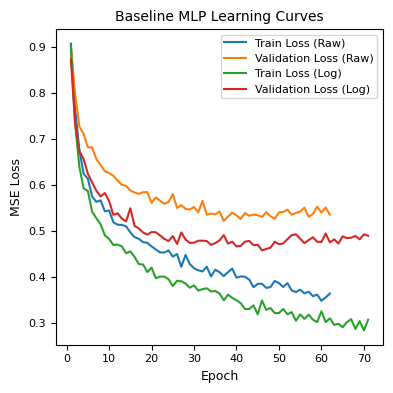

In [52]:
#| label: fig-mlp-learning-curves
#| fig-cap: "Training and validation loss curves for the raw-feature and log-transformed-feature baseline MLP pipelines."

plt.figure(figsize=(4, 4))

plt.plot(history_raw["epoch"], history_raw["train_loss"], label="Train Loss (Raw)")
plt.plot(history_raw["epoch"], history_raw["val_loss"], label="Validation Loss (Raw)")
plt.plot(history_log["epoch"], history_log["train_loss"], label="Train Loss (Log)")
plt.plot(history_log["epoch"], history_log["val_loss"], label="Validation Loss (Log)")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Baseline MLP Learning Curves")
plt.legend()
plt.tight_layout()
plt.show()

In [53]:
# MLP predictions
y_pred_raw_scaled = predict_mlp(mlp_raw, val_loader_raw, device=device)
ylog_pred_log_scaled = predict_mlp(mlp_log, val_loader_log, device=device)

# Reverse scaling for original scale
ylog_val_np = ylog_val_scaled
ylog_pred_raw = scaler_ylog.inverse_transform(y_pred_raw_scaled)
ylog_pred_log = scaler_ylog.inverse_transform(ylog_pred_log_scaled)
ylog_val_true = scaler_ylog.inverse_transform(ylog_val_np)

# Evaluate for average RMSE & R2
overall_raw = evaluate_regression(ylog_val_true, ylog_pred_raw)
overall_log = evaluate_regression(ylog_val_true, ylog_pred_log)

In [54]:
#| label: tbl-mlp-val-metrics-overall
#| tbl-cap: "Validation-set regression metrics comparing the raw-feature and log-transformed-feature baseline MLP pipelines for predicting log1p(FEMA IHP). Metrics include RMSE and R² to summarize prediction error and variance explained."

rows = []


rows.append({
    "Metric": "RMSE",
    "Raw Features": round(overall_raw["rmse"], 6),
    "Log-Transformed Features": round(overall_log["rmse"], 6)
})

rows.append({
    "Metric": "R²",
    "Raw Features": round(overall_raw["r2"], 6),
    "Log-Transformed Features": round(overall_log["r2"], 6)
})

overall_metrics = pd.DataFrame(rows)

display(overall_metrics.style.hide(axis="index"))

Metric,Raw Features,Log-Transformed Features
RMSE,2.043005,1.913993
R²,0.531866,0.589123


The overall metric comparison in @fig-mlp-feature-pipeline-comparison further supports the log-transformed feature pipeline. Relative to the raw-feature pipeline, the log-transformed pipeline achieves both lower validation RMSE and higher validation $R^2$. While the improvement is not large, it is consistent across both metrics and indicates that the transformed representation provides a modest performance benefit for predicting `log1p(FEMA IHP)`.

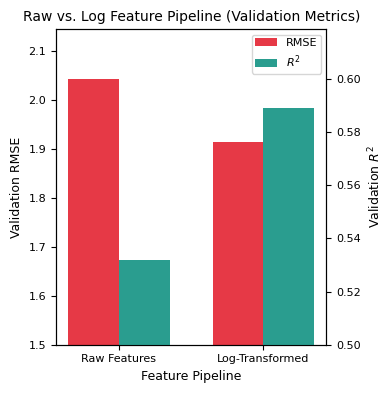

In [55]:
#| label: fig-mlp-feature-pipeline-comparison
#| fig-cap: "Validation-set comparison between the raw-feature and log-transformed-feature MLP pipelines for predicting log1p(FEMA IHP)."

rmse_vals = np.array([overall_raw["rmse"], overall_log["rmse"]])
r2_vals = np.array([overall_raw["r2"], overall_log["r2"]])
pipelines = ["Raw Features", "Log-Transformed"]

x = np.arange(len(pipelines))
width = 0.35

# Optional axis limits
rmse_ylim = (1.5)     # e.g., (1.8, 2.2)
r2_ylim = (0.5)       # e.g., (0.5, 0.65)

fig, ax1 = plt.subplots(figsize=(4, 4))

bars1 = ax1.bar(
    x - width / 2,
    rmse_vals,
    width,
    label="RMSE",
    color="#e63946"
)

ax1.set_ylabel("Validation RMSE")
ax1.set_xticks(x)
ax1.set_xticklabels(pipelines)
ax1.set_xlabel("Feature Pipeline")
ax1.set_title("Raw vs. Log Feature Pipeline (Validation Metrics)")

if rmse_ylim is not None:
    ax1.set_ylim(rmse_ylim)

ax2 = ax1.twinx()

bars2 = ax2.bar(
    x + width / 2,
    r2_vals,
    width,
    label="$R^2$",
    color="#2a9d8f"
)

ax2.set_ylabel("Validation $R^2$")

if r2_ylim is not None:
    ax2.set_ylim(r2_ylim)

ax1.legend(
    [bars1[0], bars2[0]],
    ["RMSE", "$R^2$"],
    loc="upper right"
)

plt.tight_layout()
plt.show()

Taken together, the feature ablation indicates that the log-transformed feature pipeline provides a modest but consistent improvement in predictive performance. The transformed representation achieves lower validation RMSE and higher validation $R^2$, suggesting that reducing skewness in several housing and access-related indicators produces **a feature space that is easier for the neural network to learn from**. By compressing extreme values in heavily skewed variables, the transformation reduces the influence of outlier counties and improves the model’s ability to generalize across the full range of observed disaster assistance outcomes.

## Architecture Ablation

To examine the role of model capacity, an architecture ablation was conducted comparing three MLP configurations of increasing depth and width: the current baseline architecture (64 → 32), a Deep-128 architecture (128 → 64 → 32), and a Deep-256 architecture (256 → 128 → 64 → 32).

In [56]:
#| label: tbl-mlp-architecture-ablation-config
#| tbl-cap: "Architecture configurations used in the MLP ablation study. The baseline, deep-128, and deep-256 variants are evaluated using both standardized raw and log-transformed features."
#| output: false

architecture_configs = {
    "Baseline (64)": [64, 32],
    "Deep-128": [128, 64, 32],
    "Deep-256": [256, 128, 64, 32],
}

architecture_config_df = pd.DataFrame({
    "Setting": [
        "Baseline Hidden Dimensions",
        "Deep-128 Hidden Dimensions",
        "Deep-256 Hidden Dimensions",
        "Dropout",
        "Learning Rate",
        "Weight Decay",
        "Max Epochs",
        "Early Stopping Patience"
    ],
    "Value": [
        str(architecture_configs["Baseline (64)"]),
        str(architecture_configs["Deep-128"]),
        str(architecture_configs["Deep-256"]),
        0.1,
        LEARNING_RATE,
        WEIGHT_DECAY,
        MAX_EPOCHS,
        PATIENCE
    ]
})

display(architecture_config_df.style.hide(axis="index"))

Setting,Value
Baseline Hidden Dimensions,"[64, 32]"
Deep-128 Hidden Dimensions,"[128, 64, 32]"
Deep-256 Hidden Dimensions,"[256, 128, 64, 32]"
Dropout,0.100000
Learning Rate,0.001000
Weight Decay,0.000100
Max Epochs,300
Early Stopping Patience,25


In [57]:
architecture_results = []

# Training loop
for architecture_name, hidden_dims in architecture_configs.items():
    for feature_name, X_train_tensor, train_loader, val_loader in [
        ("Raw Features", Xraw_train_t, train_loader_raw, val_loader_raw),
        ("Log-Transformed Features", Xlog_train_t, train_loader_log, val_loader_log),
    ]:
        set_seed(SEED)

        model = FlexibleMLP(
            input_dim=X_train_tensor.shape[1],
            hidden_dims=hidden_dims,
            output_dim=ylog_train_t.shape[1],
            dropout=0.1,
        )

        optimizer = build_optimizer(
            model=model,
            learning_rate=LEARNING_RATE,
            weight_decay=WEIGHT_DECAY,
        )

        model, history, best_epoch, best_val_loss = train_mlp(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            optimizer=optimizer,
            max_epochs=MAX_EPOCHS,
            patience=PATIENCE,
            device=device,
        )

        ylog_pred_scaled = predict_mlp(model, val_loader, device=device)
        ylog_pred = scaler_ylog.inverse_transform(ylog_pred_scaled)
        ylog_true = scaler_ylog.inverse_transform(ylog_val_scaled)

        overall_metrics = evaluate_regression(ylog_true, ylog_pred)

        architecture_results.append({
            "Architecture": architecture_name,
            "Feature Pipeline": feature_name,
            "Hidden Dimensions": str(hidden_dims),
            "Dropout": 0.1,
            "Weight Decay": WEIGHT_DECAY,
            "Trainable Parameters": count_parameters(model),
            "Epochs Trained": len(history["epoch"]),
            "Best Epoch": best_epoch,
            "Best Validation Loss": best_val_loss,
            "Validation RMSE": overall_metrics["rmse"],
            "Validation R²": overall_metrics["r2"],
            "History": history,
            "Model": model
        })

In [58]:
#| label: tbl-mlp-architecture-ablation
#| tbl-cap: "Architecture ablation results for the MLP benchmark using standardized raw and log-transformed features. Performance is summarized using RMSE and R² on the validation set for predicting log1p(FEMA IHP)."
#| output: false

architecture_results_df = pd.DataFrame(architecture_results)

architecture_summary = architecture_results_df[
    [
        "Architecture",
        "Feature Pipeline",
        "Hidden Dimensions",
        "Trainable Parameters",
        "Epochs Trained",
        "Best Epoch",
        "Best Validation Loss",
        "Validation RMSE",
        "Validation R²"
    ]
].copy()

architecture_summary["Best Validation Loss"] = architecture_summary["Best Validation Loss"].round(6)
architecture_summary["Validation RMSE"] = architecture_summary["Validation RMSE"].round(6)
architecture_summary["Validation R²"] = architecture_summary["Validation R²"].round(6)

# Create experiment labels
architecture_summary["Experiment"] = (
    architecture_summary["Architecture"] + " | " + architecture_summary["Feature Pipeline"]
)

architecture_summary = architecture_summary.drop(
    columns=["Architecture", "Feature Pipeline"]
)

architecture_summary = architecture_summary.set_index("Experiment").T

display(architecture_summary)

Experiment,Baseline (64) | Raw Features,Baseline (64) | Log-Transformed Features,Deep-128 | Raw Features,Deep-128 | Log-Transformed Features,Deep-256 | Raw Features,Deep-256 | Log-Transformed Features
Hidden Dimensions,"[64, 32]","[64, 32]","[128, 64, 32]","[128, 64, 32]","[256, 128, 64, 32]","[256, 128, 64, 32]"
Trainable Parameters,3137,3137,12417,12417,47361,47361
Epochs Trained,91,57,53,46,49,45
Best Epoch,66,32,28,21,24,20
Best Validation Loss,0.505444,0.475297,0.506342,0.461894,0.511645,0.47899
Validation RMSE,2.009736,1.948879,2.01152,1.921203,2.022026,1.956436
Validation R²,0.546988,0.574008,0.546183,0.586021,0.541431,0.570698


As shown in @fig-mlp-architecture-ablation, increasing network capacity produces different effects across the two feature pipelines. For the log-transformed feature pipeline, the **Deep-128 architecture achieves the best validation performance**, with the lowest RMSE and highest $R^2$. In contrast, the Deep-256 variant shows no further improvement and slightly worse validation metrics, suggesting diminishing returns from additional model capacity.

For the raw-feature pipeline, performance differences across architectures are relatively small, with all three models producing similar validation errors. However, the deeper architectures do not provide a consistent advantage and in some cases slightly increase prediction error.

Overall, these results suggest that a moderate increase in network capacity can be beneficial when the feature representation is well-conditioned (as with the log-transformed features), but larger architectures do not improve generalization. The Deep-128 architecture with log-transformed features therefore provides the best balance between representational flexibility and validation performance.

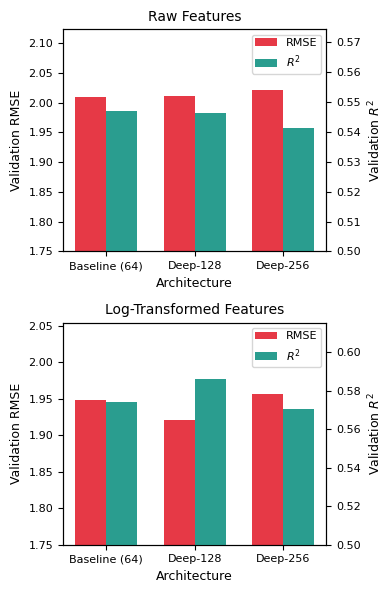

In [59]:
#| label: fig-mlp-architecture-ablation
#| fig-cap: "Validation performance for the MLP architecture ablation across baseline, deep-128, and deep-256 variants using standardized raw and log-transformed features. RMSE (left axis) and $R^2$ (right axis) summarize predictive accuracy for log1p(FEMA IHP)."

architectures = list(architecture_configs.keys())
x = np.arange(len(architectures))
width = 0.35

raw_rmse = [
    architecture_results_df[
        (architecture_results_df["Architecture"] == arch) &
        (architecture_results_df["Feature Pipeline"] == "Raw Features")
    ]["Validation RMSE"].iloc[0]
    for arch in architectures
]

log_rmse = [
    architecture_results_df[
        (architecture_results_df["Architecture"] == arch) &
        (architecture_results_df["Feature Pipeline"] == "Log-Transformed Features")
    ]["Validation RMSE"].iloc[0]
    for arch in architectures
]

raw_r2 = [
    architecture_results_df[
        (architecture_results_df["Architecture"] == arch) &
        (architecture_results_df["Feature Pipeline"] == "Raw Features")
    ]["Validation R²"].iloc[0]
    for arch in architectures
]

log_r2 = [
    architecture_results_df[
        (architecture_results_df["Architecture"] == arch) &
        (architecture_results_df["Feature Pipeline"] == "Log-Transformed Features")
    ]["Validation R²"].iloc[0]
    for arch in architectures
]

rmse_ylim = (1.75)
r2_ylim = (0.5)

fig, axes = plt.subplots(2, 1, figsize=(4, 6), sharey=False)

for ax, rmse_vals, r2_vals, title in [
    (axes[0], raw_rmse, raw_r2, "Raw Features"),
    (axes[1], log_rmse, log_r2, "Log-Transformed Features"),
]:

    bars1 = ax.bar(
        x - width / 2,
        rmse_vals,
        width,
        label="RMSE",
        color="#e63946"
    )

    ax.set_ylabel("Validation RMSE")
    ax.set_xticks(x)
    ax.set_xticklabels(architectures)
    ax.set_xlabel("Architecture")
    ax.set_title(title)

    if rmse_ylim is not None:
        ax.set_ylim(rmse_ylim)

    ax2 = ax.twinx()

    bars2 = ax2.bar(
        x + width / 2,
        r2_vals,
        width,
        label="$R^2$",
        color="#2a9d8f"
    )

    ax2.set_ylabel("Validation $R^2$")

    if r2_ylim is not None:
        ax2.set_ylim(r2_ylim)

    ax.legend(
        [bars1[0], bars2[0]],
        ["RMSE", "$R^2$"],
        loc="upper right"
)

plt.tight_layout()
plt.show()

## Regularization Ablation

The last ablation study was conducted to examine the impact of regularization on model generalization. Two forms of regularization were evaluated independently: **dropout** and **weight decay**. In both experiments the architecture, optimizer, and training schedule were held fixed to isolate the effect of the regularization mechanism itself.

### Dropout Ablation

The first experiment evaluated the effect of **dropout strength** within the Deep-128 network. Three dropout values were tested—**0.0, 0.1, and 0.3** while keeping all other training settings constant. Each configuration was trained using both the raw and log-transformed pipelines.

In [60]:
#| label: tbl-mlp-dropout-ablation-config
#| tbl-cap: "Dropout configurations used in the MLP regularization ablation study. The Deep-128 architecture is held fixed while dropout strength is varied to evaluate its effect on generalization for both standardized raw and log-transformed features."
#| output: false

dropout_configs = [0.0, 0.1, 0.3]
dropout_hidden_dims = [128, 64, 32]

dropout_config_df = pd.DataFrame({
    "Setting": [
        "Architecture",
        "Dropout Values",
        "Learning Rate",
        "Weight Decay",
        "Max Epochs",
        "Early Stopping Patience"
    ],
    "Value": [
        str(dropout_hidden_dims),
        str(dropout_configs),
        LEARNING_RATE,
        WEIGHT_DECAY,
        MAX_EPOCHS,
        PATIENCE
    ]
})

display(dropout_config_df.style.hide(axis="index"))

Setting,Value
Architecture,"[128, 64, 32]"
Dropout Values,"[0.0, 0.1, 0.3]"
Learning Rate,0.001000
Weight Decay,0.000100
Max Epochs,300
Early Stopping Patience,25


In [61]:
dropout_results = []

# Training loop
for dropout_value in dropout_configs:
    for feature_name, X_train_tensor, train_loader, val_loader in [
        ("Raw Features", Xraw_train_t, train_loader_raw, val_loader_raw),
        ("Log-Transformed Features", Xlog_train_t, train_loader_log, val_loader_log),
    ]:
        set_seed(SEED)

        model = FlexibleMLP(
            input_dim=X_train_tensor.shape[1],
            hidden_dims=dropout_hidden_dims,
            output_dim=ylog_train_t.shape[1],
            dropout=dropout_value,
        )

        optimizer = build_optimizer(
            model=model,
            learning_rate=LEARNING_RATE,
            weight_decay=WEIGHT_DECAY,
        )

        model, history, best_epoch, best_val_loss = train_mlp(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            optimizer=optimizer,
            max_epochs=MAX_EPOCHS,
            patience=PATIENCE,
            device=device,
        )

        ylog_pred_scaled = predict_mlp(model, val_loader, device=device)
        ylog_pred = scaler_ylog.inverse_transform(ylog_pred_scaled)
        ylog_true = scaler_ylog.inverse_transform(ylog_val_scaled)

        overall_metrics = evaluate_regression(ylog_true, ylog_pred)

        dropout_results.append({
            "Dropout": dropout_value,
            "Feature Pipeline": feature_name,
            "Hidden Dimensions": str(dropout_hidden_dims),
            "Weight Decay": WEIGHT_DECAY,
            "Trainable Parameters": count_parameters(model),
            "Epochs Trained": len(history["epoch"]),
            "Best Epoch": best_epoch,
            "Best Validation Loss": best_val_loss,
            "Validation RMSE": overall_metrics["rmse"],
            "Validation R²": overall_metrics["r2"],
            "History": history,
            "Model": model
        })

In [62]:
#| label: tbl-mlp-dropout-ablation
#| tbl-cap: "Dropout ablation results for the Deep-128 MLP using standardized raw and log-transformed features. Performance is summarized using validation RMSE and R² for predicting log1p(FEMA IHP)."
#| output: false

dropout_results_df = pd.DataFrame(dropout_results)

dropout_summary = dropout_results_df[
    [
        "Dropout",
        "Feature Pipeline",
        "Trainable Parameters",
        "Epochs Trained",
        "Best Epoch",
        "Best Validation Loss",
        "Validation RMSE",
        "Validation R²"
    ]
].copy()

dropout_summary["Best Validation Loss"] = dropout_summary["Best Validation Loss"].round(6)
dropout_summary["Validation RMSE"] = dropout_summary["Validation RMSE"].round(6)
dropout_summary["Validation R²"] = dropout_summary["Validation R²"].round(6)

dropout_summary["Experiment"] = (
    "Dropout=" + dropout_summary["Dropout"].astype(str) +
    " | " + dropout_summary["Feature Pipeline"]
)

dropout_summary = dropout_summary.drop(columns=["Dropout", "Feature Pipeline"])
dropout_summary = dropout_summary.set_index("Experiment").T

display(dropout_summary)

Experiment,Dropout=0.0 | Raw Features,Dropout=0.0 | Log-Transformed Features,Dropout=0.1 | Raw Features,Dropout=0.1 | Log-Transformed Features,Dropout=0.3 | Raw Features,Dropout=0.3 | Log-Transformed Features
Trainable Parameters,12417.000000,12417.000000,12417.000000,12417.000000,12417.000000,12417.000000
Epochs Trained,50.000000,37.000000,53.000000,46.000000,91.000000,62.000000
Best Epoch,25.000000,12.000000,28.000000,21.000000,66.000000,37.000000
Best Validation Loss,0.512243,0.480148,0.506342,0.461894,0.497906,0.479271
Validation RMSE,2.023207,1.958799,2.011520,1.921203,1.994692,1.957009
Validation R²,0.540894,0.569660,0.546183,0.586021,0.553745,0.570446


In [63]:
#| label: tbl-mlp-dropout-ablation-metrics
#| tbl-cap: "Validation performance for the MLP dropout ablation study using the Deep-128 architecture with standardized raw and log-transformed features. Metrics are reported as RMSE and R² for predicting log1p(FEMA IHP)."
#| output: false

dropout_metrics = dropout_results_df[
    [
        "Dropout",
        "Feature Pipeline",
        "Validation RMSE",
        "Validation R²"
    ]
].copy()

dropout_metrics["Validation RMSE"] = dropout_metrics["Validation RMSE"].round(6)
dropout_metrics["Validation R²"] = dropout_metrics["Validation R²"].round(6)

dropout_metrics["Experiment"] = (
    "Dropout=" + dropout_metrics["Dropout"].astype(str) +
    " | " + dropout_metrics["Feature Pipeline"]
)

dropout_metrics = dropout_metrics.drop(columns=["Dropout", "Feature Pipeline"])
dropout_metrics = dropout_metrics.set_index("Experiment").T

display(dropout_metrics)

Experiment,Dropout=0.0 | Raw Features,Dropout=0.0 | Log-Transformed Features,Dropout=0.1 | Raw Features,Dropout=0.1 | Log-Transformed Features,Dropout=0.3 | Raw Features,Dropout=0.3 | Log-Transformed Features
Validation RMSE,2.023207,1.958799,2.011520,1.921203,1.994692,1.957009
Validation R²,0.540894,0.569660,0.546183,0.586021,0.553745,0.570446


The dropout ablation reveals a **modest relationship between dropout strength and predictive performance** (@fig-mlp-dropout-ablation). For the raw feature pipeline, validation RMSE changes only slightly across dropout settings, indicating that regularization has limited impact on model performance. In contrast, the log-transformed pipeline shows improved performance with moderate dropout (0.1), which achieves the lowest RMSE and highest $R^2$ among the tested configurations. Stronger regularization (dropout = 0.3) leads to higher prediction error for both pipelines, suggesting that excessive dropout removes useful signal from the relatively small feature space.

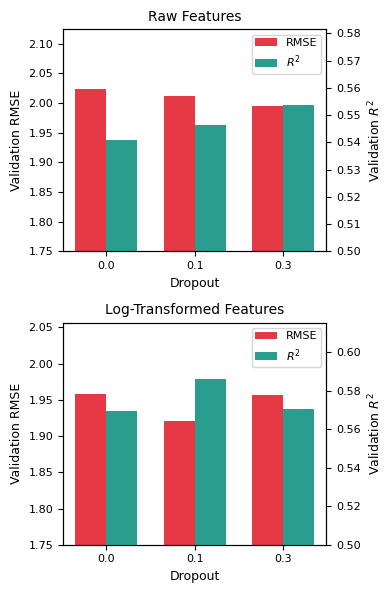

In [64]:
#| label: fig-mlp-dropout-ablation
#| fig-cap: "Validation performance for the MLP dropout ablation study using the Deep-128 architecture across multiple dropout strengths for standardized raw and log-transformed features. RMSE (left axis) and $R^2$ (right axis) summarize predictive accuracy for log1p(FEMA IHP)."

dropout_values = dropout_configs
x = np.arange(len(dropout_values))
width = 0.35

raw_rmse = [
    dropout_results_df[
        (dropout_results_df["Dropout"] == d) &
        (dropout_results_df["Feature Pipeline"] == "Raw Features")
    ]["Validation RMSE"].iloc[0]
    for d in dropout_values
]

log_rmse = [
    dropout_results_df[
        (dropout_results_df["Dropout"] == d) &
        (dropout_results_df["Feature Pipeline"] == "Log-Transformed Features")
    ]["Validation RMSE"].iloc[0]
    for d in dropout_values
]

raw_r2 = [
    dropout_results_df[
        (dropout_results_df["Dropout"] == d) &
        (dropout_results_df["Feature Pipeline"] == "Raw Features")
    ]["Validation R²"].iloc[0]
    for d in dropout_values
]

log_r2 = [
    dropout_results_df[
        (dropout_results_df["Dropout"] == d) &
        (dropout_results_df["Feature Pipeline"] == "Log-Transformed Features")
    ]["Validation R²"].iloc[0]
    for d in dropout_values
]

rmse_ylim = (1.75)   # e.g., (1.85, 2.10)
r2_ylim = (0.5)     # e.g., (0.52, 0.62)

fig, axes = plt.subplots(2, 1, figsize=(4, 6), sharey=False)

for ax, rmse_vals, r2_vals, title in [
    (axes[0], raw_rmse, raw_r2, "Raw Features"),
    (axes[1], log_rmse, log_r2, "Log-Transformed Features"),
]:
    bars1 = ax.bar(
        x - width / 2,
        rmse_vals,
        width,
        label="RMSE",
        color="#e63946"
    )

    ax.set_ylabel("Validation RMSE")
    ax.set_xticks(x)
    ax.set_xticklabels([str(d) for d in dropout_values])
    ax.set_xlabel("Dropout")
    ax.set_title(title)

    if rmse_ylim is not None:
        ax.set_ylim(rmse_ylim)

    ax2 = ax.twinx()

    bars2 = ax2.bar(
        x + width / 2,
        r2_vals,
        width,
        label="$R^2$",
        color="#2a9d8f"
    )

    ax2.set_ylabel("Validation $R^2$")

    if r2_ylim is not None:
        ax2.set_ylim(r2_ylim)

    ax.legend(
        [bars1[0], bars2[0]],
        ["RMSE", "$R^2$"],
        loc="upper right"
    )

plt.tight_layout()
plt.show()

Overall, these results indicate that light regularization provides the best balance between model flexibility and generalization. The best-performing configuration from the dropout ablation is therefore the Deep-128 architecture with **dropout = 0.1** using the log-transformed feature pipeline.

### Weight Decay Ablation

The second regularization experiment evaluated L2 weight decay while keeping dropout fixed. Three weight decay values were tested—**0.0, 1e-3, and 1e-5**—using the same architecture and training settings.

In [65]:
#| label: tbl-mlp-weight-decay-ablation-config
#| tbl-cap: "Weight decay configurations used in the MLP regularization ablation study. The Deep-128 architecture and dropout = 0.1 setting are held fixed while weight decay is varied to evaluate its effect on generalization for both standardized raw and log-transformed features."

weight_decay_configs = [0.0, 1e-3, 1e-5]
weight_decay_hidden_dims = [128, 64, 32]
best_dropout = 0.1

weight_decay_config_df = pd.DataFrame({
    "Setting": [
        "Architecture",
        "Dropout",
        "Weight Decay Values",
        "Learning Rate",
        "Max Epochs",
        "Early Stopping Patience"
    ],
    "Value": [
        str(weight_decay_hidden_dims),
        best_dropout,
        str(weight_decay_configs),
        LEARNING_RATE,
        MAX_EPOCHS,
        PATIENCE
    ]
})

display(weight_decay_config_df.style.hide(axis="index"))

Setting,Value
Architecture,"[128, 64, 32]"
Dropout,0.100000
Weight Decay Values,"[0.0, 0.001, 1e-05]"
Learning Rate,0.001000
Max Epochs,300
Early Stopping Patience,25


In [66]:
weight_decay_results = []

# Training loop
for weight_decay_value in weight_decay_configs:
    for feature_name, X_train_tensor, train_loader, val_loader in [
        ("Raw Features", Xraw_train_t, train_loader_raw, val_loader_raw),
        ("Log-Transformed Features", Xlog_train_t, train_loader_log, val_loader_log),
    ]:
        set_seed(SEED)

        model = FlexibleMLP(
            input_dim=X_train_tensor.shape[1],
            hidden_dims=weight_decay_hidden_dims,
            output_dim=ylog_train_t.shape[1],
            dropout=best_dropout,
        )

        optimizer = build_optimizer(
            model=model,
            learning_rate=LEARNING_RATE,
            weight_decay=weight_decay_value,
        )

        model, history, best_epoch, best_val_loss = train_mlp(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            optimizer=optimizer,
            max_epochs=MAX_EPOCHS,
            patience=PATIENCE,
            device=device,
        )

        ylog_pred_scaled = predict_mlp(model, val_loader, device=device)
        ylog_pred = scaler_ylog.inverse_transform(ylog_pred_scaled)
        ylog_true = scaler_ylog.inverse_transform(ylog_val_scaled)

        overall_metrics = evaluate_regression(ylog_true, ylog_pred)

        weight_decay_results.append({
            "Weight Decay": weight_decay_value,
            "Feature Pipeline": feature_name,
            "Hidden Dimensions": str(weight_decay_hidden_dims),
            "Dropout": best_dropout,
            "Trainable Parameters": count_parameters(model),
            "Epochs Trained": len(history["epoch"]),
            "Best Epoch": best_epoch,
            "Best Validation Loss": best_val_loss,
            "Validation RMSE": overall_metrics["rmse"],
            "Validation R²": overall_metrics["r2"],
            "History": history,
            "Model": model
        })

In [67]:
#| label: tbl-mlp-weight-decay-ablation
#| tbl-cap: "Weight decay ablation results for the Deep-128 MLP with dropout = 0.1 using standardized raw and log-transformed features. Performance is summarized using validation RMSE and R² for predicting log1p(FEMA IHP)."
#| output: false

weight_decay_results_df = pd.DataFrame(weight_decay_results)

weight_decay_summary = weight_decay_results_df[
    [
        "Weight Decay",
        "Feature Pipeline",
        "Trainable Parameters",
        "Epochs Trained",
        "Best Epoch",
        "Best Validation Loss",
        "Validation RMSE",
        "Validation R²"
    ]
].copy()

weight_decay_summary["Best Validation Loss"] = weight_decay_summary["Best Validation Loss"].round(6)
weight_decay_summary["Validation RMSE"] = weight_decay_summary["Validation RMSE"].round(6)
weight_decay_summary["Validation R²"] = weight_decay_summary["Validation R²"].round(6)

weight_decay_summary["Experiment"] = (
    "WD=" + weight_decay_summary["Weight Decay"].astype(str) +
    " | " + weight_decay_summary["Feature Pipeline"]
)

weight_decay_summary = weight_decay_summary.drop(columns=["Weight Decay", "Feature Pipeline"])
weight_decay_summary = weight_decay_summary.set_index("Experiment").T

display(weight_decay_summary)

Experiment,WD=0.0 | Raw Features,WD=0.0 | Log-Transformed Features,WD=0.001 | Raw Features,WD=0.001 | Log-Transformed Features,WD=1e-05 | Raw Features,WD=1e-05 | Log-Transformed Features
Trainable Parameters,12417.000000,12417.000000,12417.000000,12417.000000,12417.000000,12417.000000
Epochs Trained,53.000000,46.000000,53.000000,69.000000,53.000000,46.000000
Best Epoch,28.000000,21.000000,28.000000,44.000000,28.000000,21.000000
Best Validation Loss,0.504769,0.461582,0.505792,0.462616,0.510059,0.459419
Validation RMSE,2.008392,1.920556,2.010426,1.922705,2.018889,1.916050
Validation R²,0.547594,0.586300,0.546677,0.585374,0.542852,0.588239


The weight decay ablation shows only minor sensitivity to L2 regularization (@fig-mlp-weight-decay-ablation). For the raw feature pipeline, RMSE changes very little across weight decay values, indicating that L2 regularization has minimal impact on model performance. In contrast, the log-transformed pipeline exhibits a slight improvement when small weight decay is introduced.

Among the tested settings, weight decay = 1e-5 produces the lowest RMSE and highest $R^2$ for the log-transformed pipeline, while larger regularization (**1e-3**) does not provide further benefit. Overall, these results suggest that the model benefits from very light L2 regularization, but performance remains largely stable across the tested values. The final configuration therefore uses the **Deep-128 architecture with dropout = 0.1 and weight decay = 1e-5**.

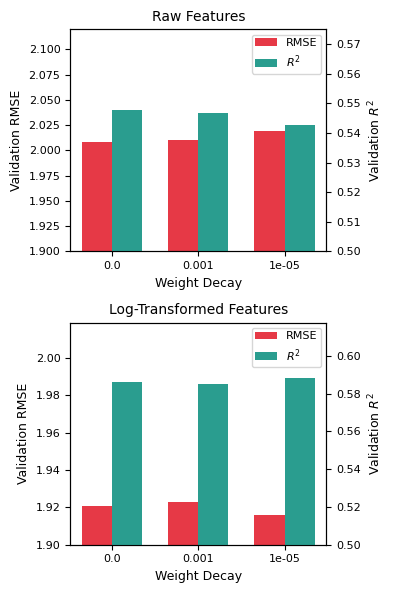

In [68]:
#| label: fig-mlp-weight-decay-ablation
#| fig-cap: "Validation performance for the MLP weight decay ablation study using the Deep-128 architecture with dropout = 0.1 across multiple weight decay strengths for standardized raw and log-transformed features. RMSE (left axis) and $R^2$ (right axis) summarize predictive accuracy for log1p(FEMA IHP)."

wd_values = weight_decay_configs
x = np.arange(len(wd_values))
width = 0.35

raw_rmse = [
    weight_decay_results_df[
        (weight_decay_results_df["Weight Decay"] == wd) &
        (weight_decay_results_df["Feature Pipeline"] == "Raw Features")
    ]["Validation RMSE"].iloc[0]
    for wd in wd_values
]

log_rmse = [
    weight_decay_results_df[
        (weight_decay_results_df["Weight Decay"] == wd) &
        (weight_decay_results_df["Feature Pipeline"] == "Log-Transformed Features")
    ]["Validation RMSE"].iloc[0]
    for wd in wd_values
]

raw_r2 = [
    weight_decay_results_df[
        (weight_decay_results_df["Weight Decay"] == wd) &
        (weight_decay_results_df["Feature Pipeline"] == "Raw Features")
    ]["Validation R²"].iloc[0]
    for wd in wd_values
]

log_r2 = [
    weight_decay_results_df[
        (weight_decay_results_df["Weight Decay"] == wd) &
        (weight_decay_results_df["Feature Pipeline"] == "Log-Transformed Features")
    ]["Validation R²"].iloc[0]
    for wd in wd_values
]

rmse_ylim = (1.9)   # e.g., (1.85, 2.05)
r2_ylim = (0.5)     # e.g., (0.52, 0.60)

fig, axes = plt.subplots(2, 1, figsize=(4, 6))

for ax, rmse_vals, r2_vals, title in [
    (axes[0], raw_rmse, raw_r2, "Raw Features"),
    (axes[1], log_rmse, log_r2, "Log-Transformed Features"),
]:
    bars1 = ax.bar(
        x - width / 2,
        rmse_vals,
        width,
        label="RMSE",
        color="#e63946"
    )

    ax.set_ylabel("Validation RMSE")
    ax.set_xticks(x)
    ax.set_xticklabels([str(wd) for wd in wd_values])
    ax.set_xlabel("Weight Decay")
    ax.set_title(title)

    if rmse_ylim is not None:
        ax.set_ylim(rmse_ylim)

    ax2 = ax.twinx()

    bars2 = ax2.bar(
        x + width / 2,
        r2_vals,
        width,
        label="$R^2$",
        color="#2a9d8f"
    )

    ax2.set_ylabel("Validation $R^2$")

    if r2_ylim is not None:
        ax2.set_ylim(r2_ylim)

    ax.legend(
        [bars1[0], bars2[0]],
        ["RMSE", "$R^2$"],
        loc="upper right"
    )

plt.tight_layout()
plt.show()

In [69]:
#| label: tbl-mlp-best-config-summary
#| tbl-cap: "Best-performing MLP configuration identified from the architecture and regularization ablations. The selected model uses log-transformed features with the Deep-128 architecture, dropout = 0.1, and weight decay = 1e-5. Metrics shown here are validation-set results used for model selection."

best_mlp_row = (
    weight_decay_results_df[
        weight_decay_results_df["Feature Pipeline"] == "Log-Transformed Features"
    ]
    .sort_values(["Validation RMSE", "Best Validation Loss"], ascending=[True, True])
    .iloc[0]
)

best_mlp_config = pd.DataFrame({
    "Metric": [
        "Feature Representation",
        "Architecture (Hidden Dimensions)",
        "Dropout",
        "Weight Decay",
        "Best Validation Epoch",
        "Best Validation Loss",
        "Validation RMSE",
        "Validation R²"
    ],
    "Value": [
        best_mlp_row["Feature Pipeline"],
        best_mlp_row["Hidden Dimensions"],
        round(best_mlp_row["Dropout"], 6),
        round(best_mlp_row["Weight Decay"], 6),
        int(best_mlp_row["Best Epoch"]),
        round(best_mlp_row["Best Validation Loss"], 6),
        round(best_mlp_row["Validation RMSE"], 6),
        round(best_mlp_row["Validation R²"], 6)
    ]
})

display(best_mlp_config.style.hide(axis="index"))

Metric,Value
Feature Representation,Log-Transformed Features
Architecture (Hidden Dimensions),"[128, 64, 32]"
Dropout,0.100000
Weight Decay,0.000010
Best Validation Epoch,21
Best Validation Loss,0.459419
Validation RMSE,1.916050
Validation R²,0.588239


## MLP Experimental Results

In the end, the ablation experiments identified a final MLP configuration using log-transformed features, the Deep-128 architecture ([128, 64, 32]), dropout = 0.1, and weight decay = 1e-5. This model achieved the best validation performance and was selected as the tabular benchmark for predicting `log1p(FEMA IHP)`.

The final held-out test evaluation shows moderate predictive performance, with test RMSE = 2.0048 and $R^2$ = 0.5712. These results indicate that county-level SVI indicators explain a meaningful portion of the variation in FEMA disaster assistance, but they do not fully capture disaster outcomes. This is expected because assistance levels depend not only on social vulnerability but also on hazard exposure, disaster severity, and federal response dynamics.

Importantly, the MLP treats counties as independent observations, relying only on tabular socioeconomic indicators. However, the exploratory analysis earlier in this study revealed strong **geographic clustering in both vulnerability and disaster assistance patterns**. Because neighboring counties often experience similar hazards and share regional socioeconomic conditions, incorporating spatial relationships may provide additional predictive signal. This motivates the transition to **graph-based models**, which represent counties as nodes in a spatial network and allow information to propagate between neighboring regions during learning.




In [70]:
#| label: tbl-final-mlp-test-evaluation
#| tbl-cap: "Held-out test-set performance for the final MLP configuration predicting log1p(FEMA IHP). The table reports the selected feature pipeline, architecture, regularization settings, parameter count, training summary, and final test metrics."

set_seed(SEED)

final_mlp_config = {
    "Feature Pipeline": "Log-Transformed Features",
    "Hidden Dimensions": [128, 64, 32],
    "Dropout": 0.1,
    "Weight Decay": 1e-5,
    "Learning Rate": LEARNING_RATE,
    "Max Epochs": MAX_EPOCHS,
    "Patience": PATIENCE,
}

final_mlp = FlexibleMLP(
    input_dim=Xlog_train_t.shape[1],
    hidden_dims=final_mlp_config["Hidden Dimensions"],
    output_dim=ylog_train_t.shape[1],
    dropout=final_mlp_config["Dropout"],
)

optimizer = build_optimizer(
    model=final_mlp,
    learning_rate=final_mlp_config["Learning Rate"],
    weight_decay=final_mlp_config["Weight Decay"],
)

final_mlp, history, best_epoch, best_val_loss = train_mlp(
    model=final_mlp,
    train_loader=train_loader_log,
    val_loader=val_loader_log,
    criterion=criterion,
    optimizer=optimizer,
    max_epochs=final_mlp_config["Max Epochs"],
    patience=final_mlp_config["Patience"],
    device=device,
)

ylog_test_pred_scaled = predict_mlp(final_mlp, test_loader_log, device=device)
ylog_test_pred = scaler_ylog.inverse_transform(ylog_test_pred_scaled)
ylog_test_true = scaler_ylog.inverse_transform(ylog_test_scaled)

test_metrics = evaluate_regression(ylog_test_true, ylog_test_pred)

final_mlp_results = pd.DataFrame([
    {
        "Model": "MLP",
        "Feature Pipeline": final_mlp_config["Feature Pipeline"],
        "Architecture": "Deep-128",
        "Hidden Dimensions": str(final_mlp_config["Hidden Dimensions"]),
        "Dropout": final_mlp_config["Dropout"],
        "Weight Decay": final_mlp_config["Weight Decay"],
        "Learning Rate": final_mlp_config["Learning Rate"],
        "Trainable Parameters": count_parameters(final_mlp),
        "Epochs Trained": len(history["epoch"]),
        "Best Epoch": best_epoch,
        "Best Validation Loss": round(best_val_loss, 6),
        "Test RMSE": round(test_metrics["rmse"], 6),
        "Test R²": round(test_metrics["r2"], 6),
    }
])

display(final_mlp_results.T.style.hide(axis="columns"))

Model,MLP
Feature Pipeline,Log-Transformed Features
Architecture,Deep-128
Hidden Dimensions,"[128, 64, 32]"
Dropout,0.100000
Weight Decay,0.000010
Learning Rate,0.001000
Trainable Parameters,12417
Epochs Trained,46
Best Epoch,21
Best Validation Loss,0.459419


In [73]:
#| output: false

# Ensure the output directories exist
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

np.savez(
    PROCESSED_DATA_DIR / "svi_processed_splits.npz",

    # Raw feature pipeline
    X_train_scaled=X_train_scaled,
    X_val_scaled=X_val_scaled,
    X_test_scaled=X_test_scaled,

    # Log feature pipeline
    Xlog_train_scaled=Xlog_train_scaled,
    Xlog_val_scaled=Xlog_val_scaled,
    Xlog_test_scaled=Xlog_test_scaled,

    # Targets (log1p FEMA IHP)
    ylog_train_scaled=ylog_train_scaled,
    ylog_val_scaled=ylog_val_scaled,
    ylog_test_scaled=ylog_test_scaled,

    # County identifiers
    fips_train=fips_train.astype(str).to_numpy(),
    fips_val=fips_val.astype(str).to_numpy(),
    fips_test=fips_test.astype(str).to_numpy(),
)

# Save scalers for inverse transforms
joblib.dump(scaler_Xlog, PROCESSED_DATA_DIR / "scaler_Xlog.pkl")
joblib.dump(scaler_ylog, PROCESSED_DATA_DIR / "scaler_ylog.pkl")

# Save final MLP artifact for GCN comparisons
final_mlp_results.to_csv(ARTIFACT_DIR / "final_mlp_results.csv", index=False)